# ARIMA modeling

Fit univariate ARIMA models to the three fuel-price series, select low-order candidates using training-set AIC, and reserve the final six months for out-of-sample evaluation.

In [4]:
# Import the libraries needed to load the data, fit ARIMA models, and assess forecasts.
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

In [5]:
# Load the cleaned data and reserve the final six months for evaluation.
df = pd.read_csv("../data/dataset_final/full_data.csv")
df["date"] = pd.to_datetime(df["month"], format="%YM%m")
df = df.set_index("date").asfreq("MS")
fuel_cols = [
    "diesel_price_(GHC/litre)",
    "petrol_price_ghs/litre",
    "lpg_ghs/kg",
]
horizon = 6
train = df.iloc[:-horizon]
test = df.iloc[-horizon:]

# The training set is used for model selection; the untouched test set measures generalization.
print(f"Training period: {train.index.min():%Y-%m} to {train.index.max():%Y-%m}")
print(f"Test period: {test.index.min():%Y-%m} to {test.index.max():%Y-%m}")

Training period: 2015-07 to 2025-12
Test period: 2026-01 to 2026-06


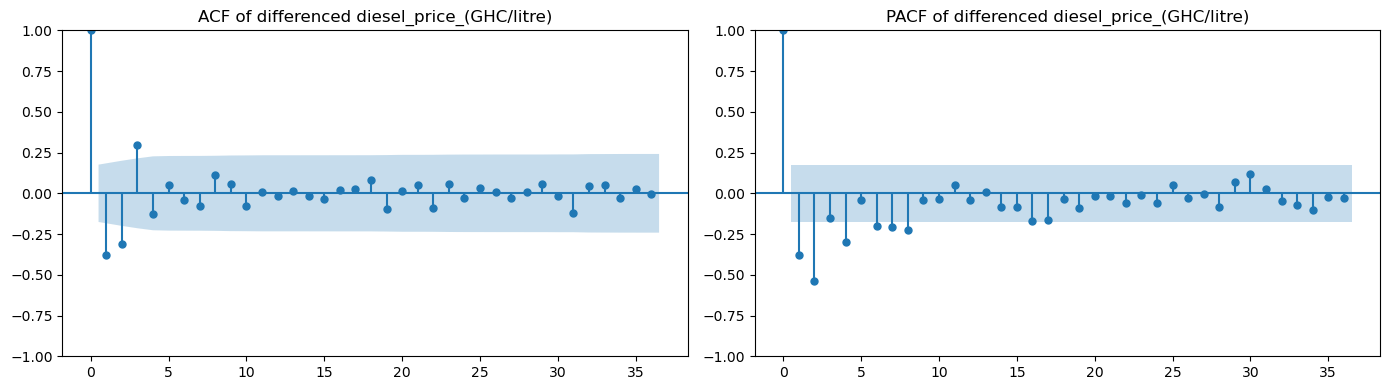

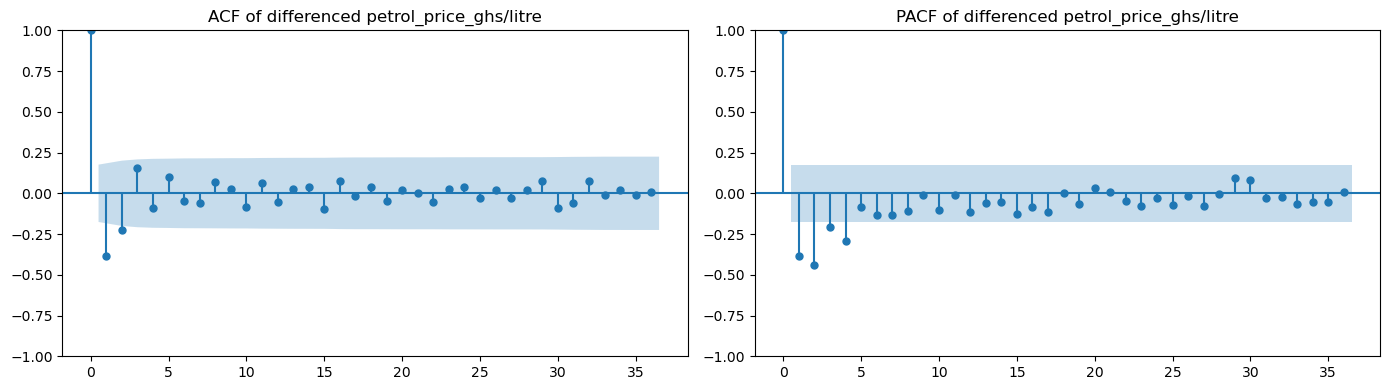

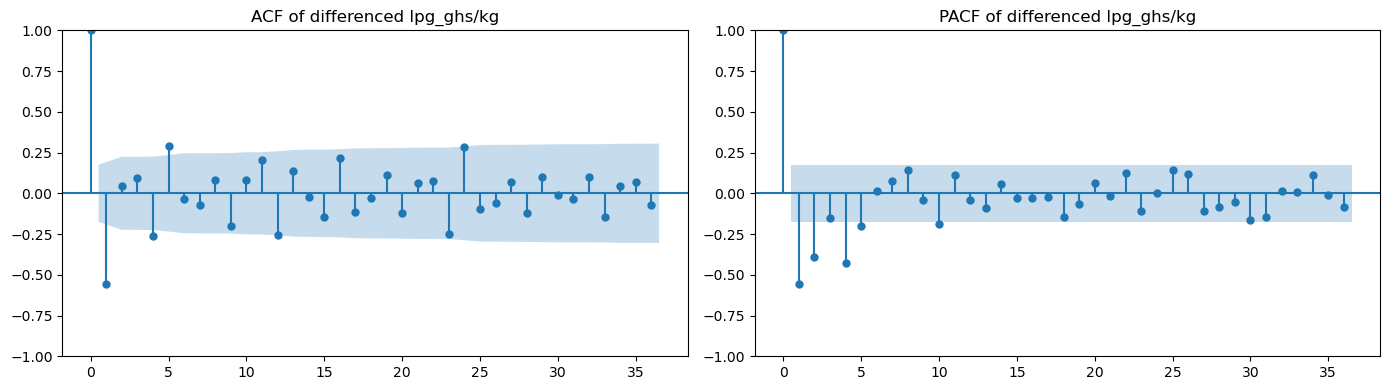

Selected orders from training data:
{'diesel_price_(GHC/litre)': (0, 1, 3), 'petrol_price_ghs/litre': (0, 1, 3), 'lpg_ghs/kg': (1, 1, 3)}


,series,order,AIC,BIC
3,diesel_price_(GHC/litre),"(0, 1, 3)",256.124830,267.307992
7,diesel_price_(GHC/litre),"(1, 1, 3)",257.870829,271.849781
6,diesel_price_(GHC/litre),"(1, 1, 2)",257.999564,269.215648
9,diesel_price_(GHC/litre),"(2, 1, 1)",259.448751,270.697489
10,diesel_price_(GHC/litre),"(2, 1, 2)",259.557835,273.577941
39,lpg_ghs/kg,"(1, 1, 3)",5.881766,19.860718
38,lpg_ghs/kg,"(1, 1, 2)",6.243842,17.459927
41,lpg_ghs/kg,"(2, 1, 1)",6.680820,17.929558
37,lpg_ghs/kg,"(1, 1, 1)",8.119397,16.555950
47,lpg_ghs/kg,"(3, 1, 3)",8.209430,27.779963


In [10]:
# Identify candidate orders and inspect each differenced fuel series.
candidate_orders = [(p, 1, q) for p in range(4) for q in range(4)]
selected_orders = {}
order_rows = []

for column in fuel_cols:
    differenced = train[column].diff().diff().dropna()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(differenced, lags=min(36, len(differenced) // 2 - 1), ax=axes[0])
    plot_pacf(
        differenced,
        lags=min(36, len(differenced) // 2 - 1),
        ax=axes[1],
        method="ywm",
    )
    axes[0].set_title(f"ACF of differenced {column}")
    axes[1].set_title(f"PACF of differenced {column}")
    plt.tight_layout()
    plt.show()

    best_order = None
    best_aic = float("inf")
    for order in candidate_orders:
        try:
            fit = ARIMA(
                train[column],
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit()
            order_rows.append(
                {
                    "series": column,
                    "order": order,
                    "AIC": fit.aic,
                    "BIC": fit.bic,
                }
            )
            if fit.aic < best_aic:
                best_order, best_aic = order, fit.aic
        except (ValueError, np.linalg.LinAlgError):
            continue
    selected_orders[column] = best_order

order_table = pd.DataFrame(order_rows).sort_values(["series", "AIC"])
print("Selected orders from training data:")
print(selected_orders)
order_table.groupby("series", group_keys=False).head(5)


Residual diagnostic summary: diesel_price_(GHC/litre)
     lb_stat  lb_pvalue
10  3.414184   0.969932


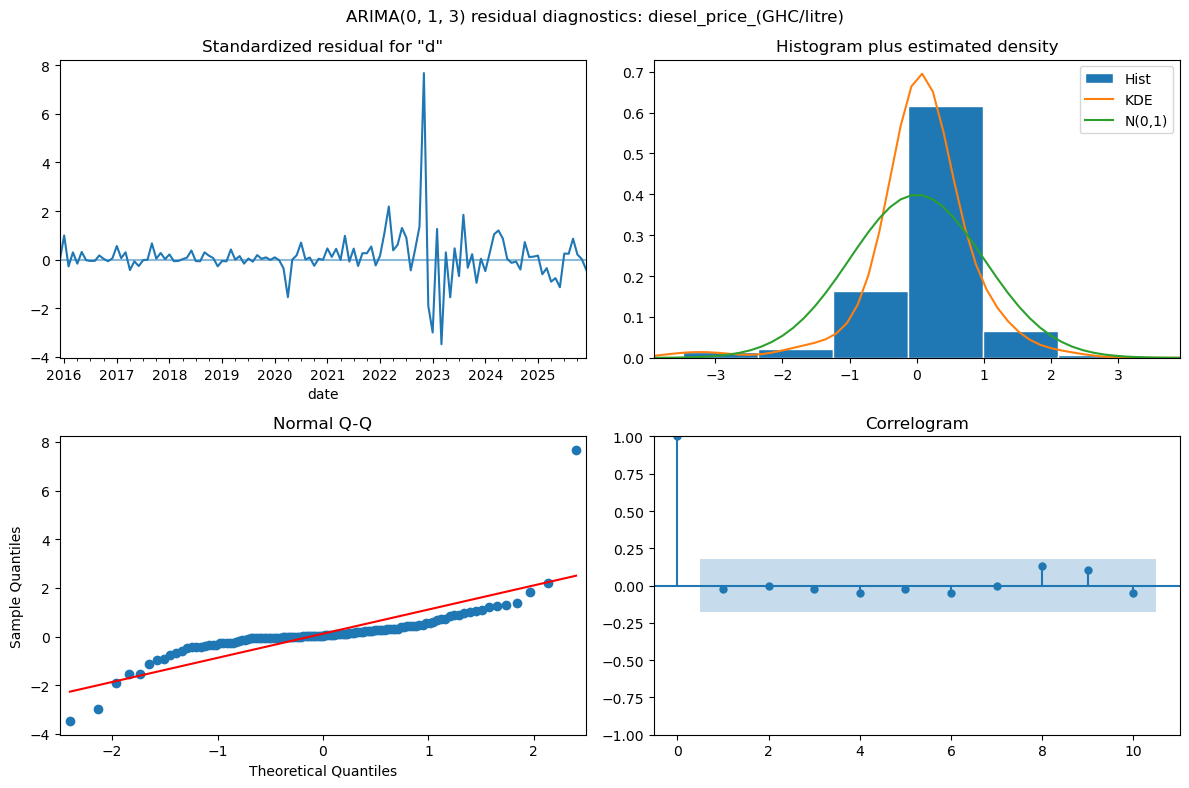


Residual diagnostic summary: petrol_price_ghs/litre
     lb_stat  lb_pvalue
10  2.303143   0.993445


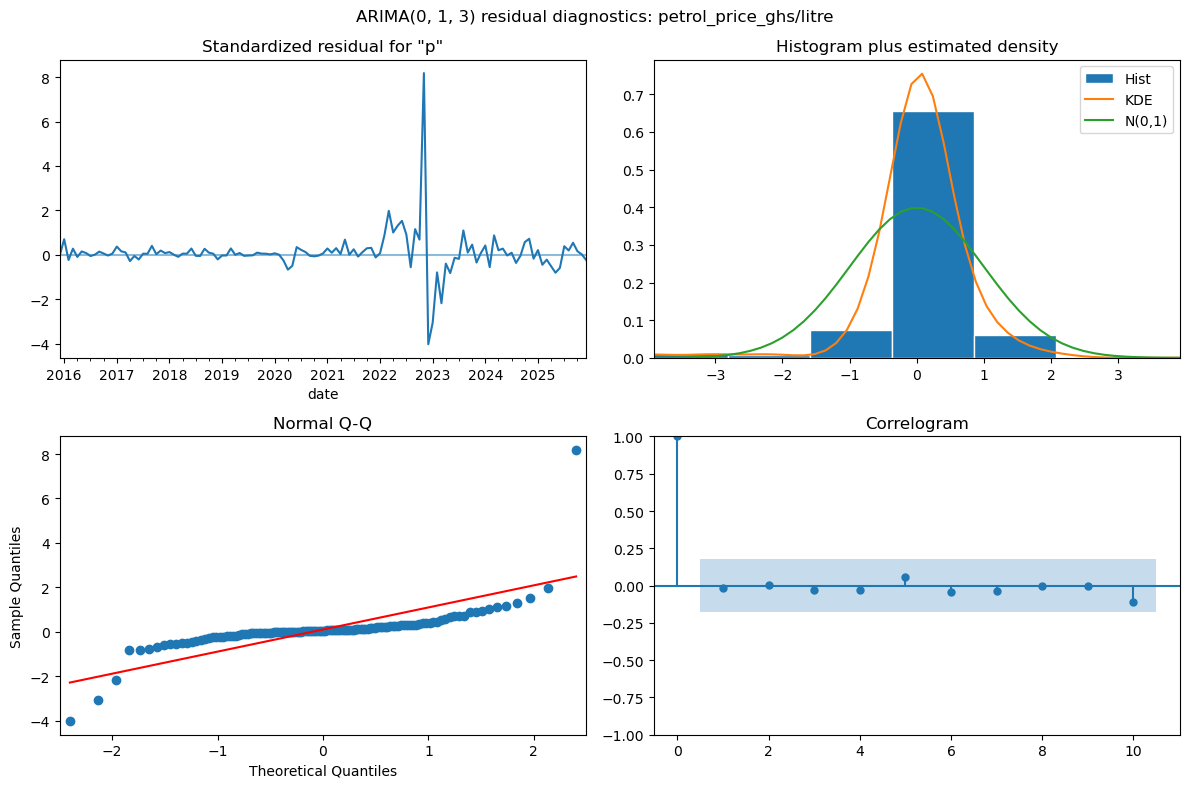


Residual diagnostic summary: lpg_ghs/kg
      lb_stat  lb_pvalue
10  19.546179   0.033849


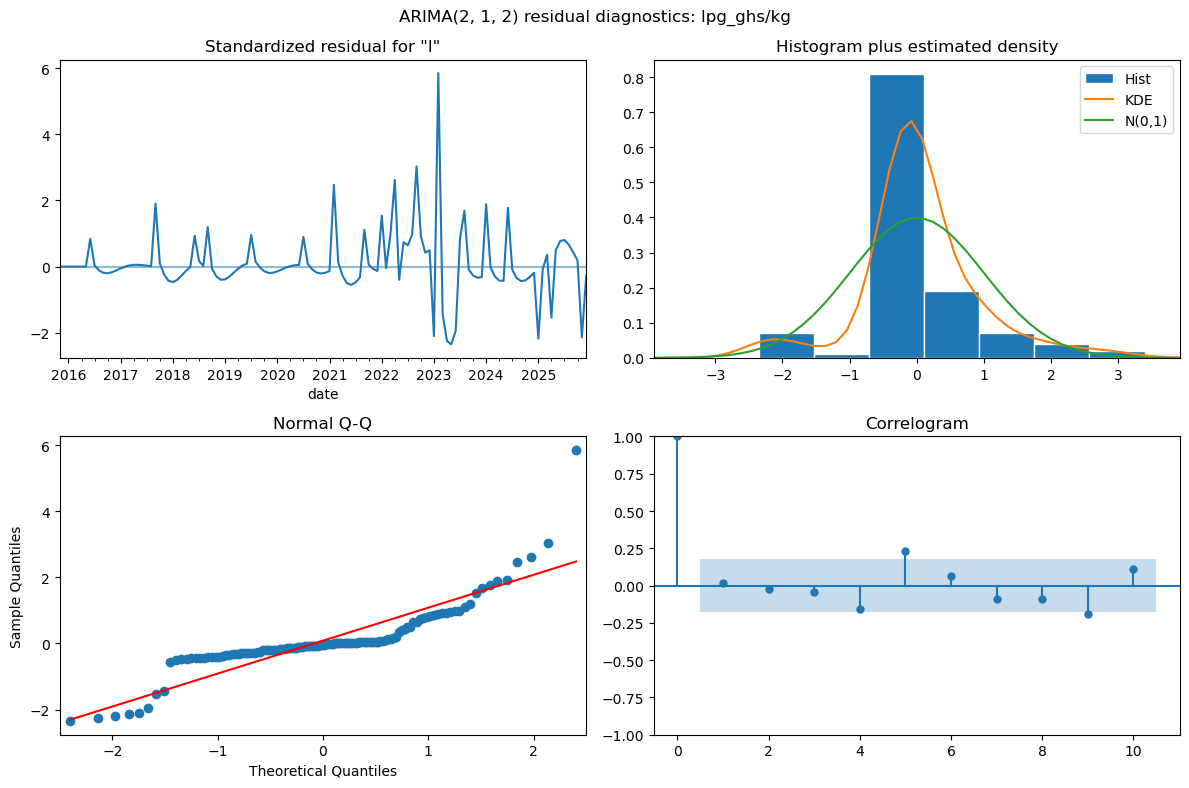


Forecast metrics:
   model                    series      order       MAE      RMSE      MAPE
0  ARIMA  diesel_price_(GHC/litre)  (0, 1, 3)  0.865237  1.024304  6.171678
1  ARIMA    petrol_price_ghs/litre  (0, 1, 3)  1.463821  1.653374  9.375929
2  ARIMA                lpg_ghs/kg  (2, 1, 2)  0.188837  0.229290  1.398790

Residual diagnostics:
                     series      order  Ljung_Box_pvalue_lag10
0  diesel_price_(GHC/litre)  (0, 1, 3)                0.969932
1    petrol_price_ghs/litre  (0, 1, 3)                0.993445
2                lpg_ghs/kg  (2, 1, 2)                0.033849


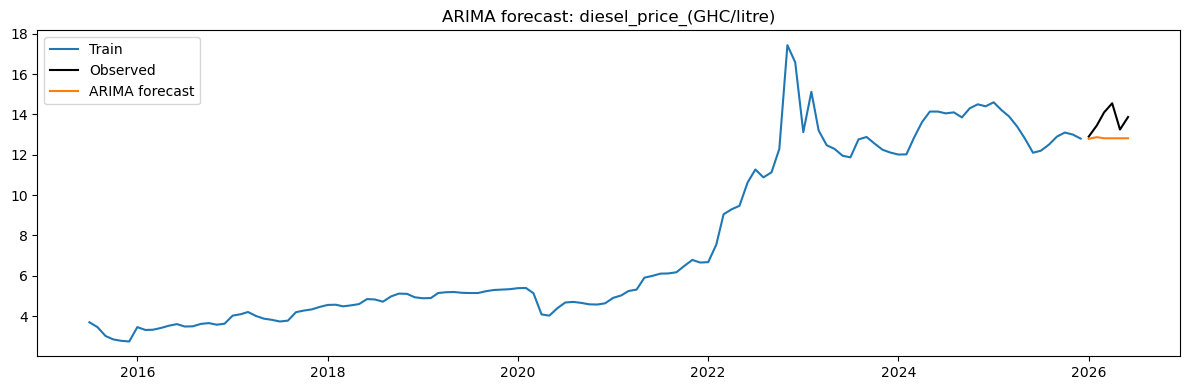

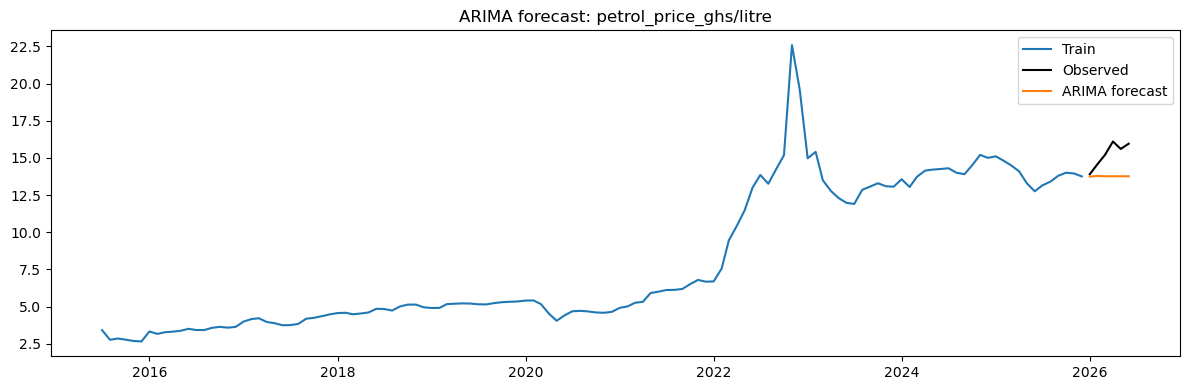

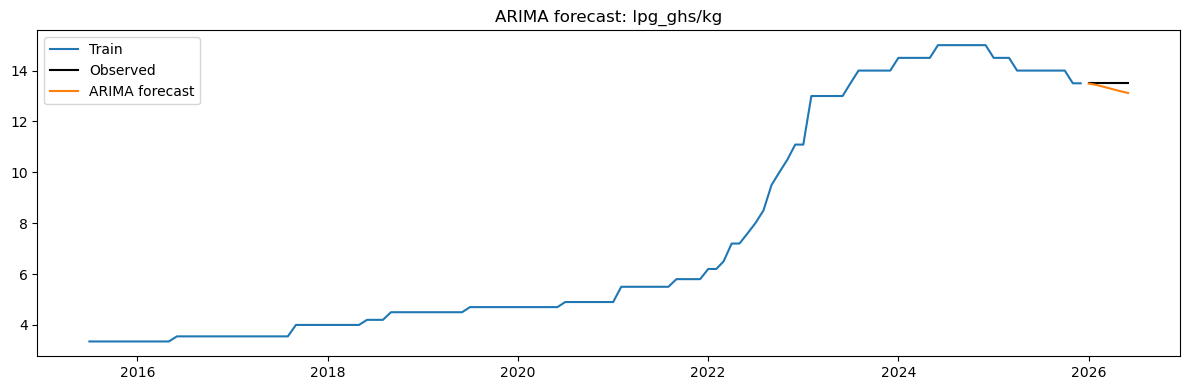

In [4]:
# Fit, diagnose, and forecast each fuel-price series.
arima_forecasts = pd.DataFrame(index=test.index)
arima_metrics = []
arima_diagnostics = []

for column, order in selected_orders.items():
    fit = ARIMA(
        train[column],
        order=order,
        enforce_stationarity=False,
    ).fit()
    forecast = fit.forecast(steps=horizon)
    arima_forecasts[column] = forecast

    residuals = fit.resid.dropna()
    ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)
    arima_diagnostics.append(
        {
            "series": column,
            "order": str(order),
            "Ljung_Box_pvalue_lag10": ljung_box["lb_pvalue"].iloc[0],
        }
    )
    print(f"\nResidual diagnostic summary: {column}")
    print(ljung_box)
    fit.plot_diagnostics(figsize=(12, 8))
    plt.suptitle(f"ARIMA{order} residual diagnostics: {column}")
    plt.tight_layout()
    plt.show()

    errors = test[column].to_numpy() - forecast.to_numpy()
    arima_metrics.append(
        {
            "model": "ARIMA",
            "series": column,
            "order": str(order),
            "MAE": mean_absolute_error(test[column], forecast),
            "RMSE": np.sqrt(mean_squared_error(test[column], forecast)),
            "MAPE": np.mean(np.abs(errors / test[column].to_numpy())) * 100,
        }
    )

arima_metrics = pd.DataFrame(arima_metrics)
arima_diagnostics = pd.DataFrame(arima_diagnostics)
print("\nForecast metrics:")
print(arima_metrics)
print("\nResidual diagnostics:")
print(arima_diagnostics)

for column in fuel_cols:
    plt.figure(figsize=(12, 4))
    plt.plot(train.index, train[column], label="Train")
    plt.plot(test.index, test[column], label="Observed", color="black")
    plt.plot(arima_forecasts.index, arima_forecasts[column], label="ARIMA forecast")
    plt.title(f"ARIMA forecast: {column}")
    plt.legend()
    plt.tight_layout()
    plt.show()